In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import stats
from pathlib import Path

In [2]:
# XLS files live in 01_data/1.3_raw_other/ng_price/ relative to project root
NG_PRICE_DIR = (Path.cwd().parents[1] / "01_data" / "1.3_raw_other" / "ng_price").resolve()  # raw .xls inputs
OUT_DIR = (Path.cwd().parents[1] / "01_data" / "3_analysis" / "ng_price").resolve()  # derived outputs
OUT_DIR.mkdir(parents=True, exist_ok=True)

def load_xls(path):
    df = pd.read_excel(
        path, sheet_name="Data 1", header=None,
        skiprows=3, names=["date", "price"], engine="xlrd"
    )
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    return df.dropna().set_index("date").sort_index()["price"]

citygate  = load_xls(NG_PRICE_DIR / "ng price citygate texas.xls")
henry_hub = load_xls(NG_PRICE_DIR / "Henry Hub NG price.xls")
elec_pwr  = load_xls(NG_PRICE_DIR / "NGprice sold to electric power consumers.xls")

# Resample all to monthly mean (Henry Hub is daily; others are already monthly)
citygate_m  = citygate.resample("MS").mean()
henry_hub_m = henry_hub.resample("MS").mean()
elec_pwr_m  = elec_pwr.resample("MS").mean()

# unit conversion: $/MCF to $/MMBtu ($/MMBtu = $/MCF / 1.038 for natural gas)
citygate_m  = citygate_m / 1.038
elec_pwr_m  = elec_pwr_m / 1.038

print(f"TX Citygate:   {citygate_m.index[0].date()} \u2192 {citygate_m.index[-1].date()}  ({len(citygate_m)} months)")
print(f"Henry Hub:     {henry_hub_m.index[0].date()} \u2192 {henry_hub_m.index[-1].date()}  ({len(henry_hub_m)} months)")
print(f"TX Elec Power: {elec_pwr_m.index[0].date()} \u2192 {elec_pwr_m.index[-1].date()}  ({len(elec_pwr_m)} months)")

TX Citygate:   1989-01-01 → 2026-02-01  (446 months)
Henry Hub:     1997-01-01 → 2026-04-01  (352 months)
TX Elec Power: 2002-01-01 → 2026-02-01  (290 months)


Saved → /Users/zyliazhang/Git/RESEARCH-PJM-ERCOT-Price-Volatility/data/other sources/NG Price/ng_price_timeseries.png


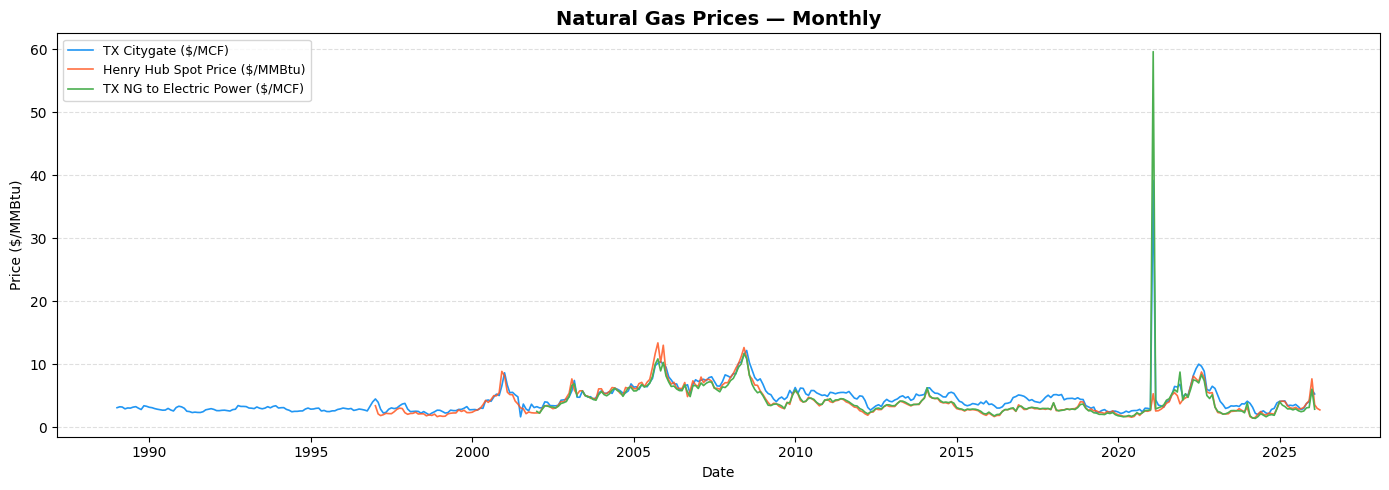

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(citygate_m.index,  citygate_m.values,  lw=1.2, label="TX Citygate ($/MCF)",             color="#2196F3")
ax.plot(henry_hub_m.index, henry_hub_m.values, lw=1.2, label="Henry Hub Spot Price ($/MMBtu)",   color="#FF5722", alpha=0.85)
ax.plot(elec_pwr_m.index,  elec_pwr_m.values,  lw=1.2, label="TX NG to Electric Power ($/MCF)", color="#4CAF50")

ax.set_title("Natural Gas Prices \u2014 Monthly", fontsize=14, fontweight="bold")
ax.set_ylabel("Price ($/MMBtu)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()

out_ts = OUT_DIR / "ng_price_timeseries.png"
fig.savefig(out_ts, dpi=150)
print(f"Saved \u2192 {out_ts}")
plt.show()

In [4]:
# Inner join on common period covered by all three series
merged = pd.DataFrame({
    "henry_hub": henry_hub_m,
    "citygate":  citygate_m,
    "elec_pwr":  elec_pwr_m,
}).dropna()

print(f"Merged: {merged.index[0].date()} \u2192 {merged.index[-1].date()}  ({len(merged)} months)")
merged.describe().round(2)

Merged: 2002-01-01 → 2026-02-01  (289 months)


,henry_hub,citygate,elec_pwr
count,289.00,289.00,289.00
mean,4.33,5.18,4.40
std,2.17,2.74,3.79
min,1.49,2.05,1.45
25%,2.82,3.66,2.83
50%,3.71,4.84,3.68
75%,5.43,5.87,5.36
max,13.42,39.18,59.61


In [5]:
def scatter_corr(x, y, xlabel, ylabel, title):
    methods_config = {
        "pearson": {
            "stat_fn": lambda x, y: stats.pearsonr(x, y),
            "symbol":  "r",
            "color":   "#E53935",
            "label":   "Pearson (OLS)",
        },
        "spearman": {
            "stat_fn": lambda x, y: stats.spearmanr(x, y),
            "symbol":  "ρ",
            "color":   "#046946",
            "label":   "Spearman (rank-OLS)",
        },
        "kendall": {
            "stat_fn": lambda x, y: stats.kendalltau(x, y),
            "symbol":  "τ",
            "color":   "#8E24AA",
            "label":   "Kendall (Theil-Sen)",
        },
    }

    ax = plt.gca()
    ax.scatter(x, y, s=14, alpha=0.55, color="#607D8B", edgecolors="none")

    xline = np.linspace(x.min(), x.max(), 200)
    annotation_lines = []

    for method, cfg in methods_config.items():
        stat, p = cfg["stat_fn"](x, y)
        pstr = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

        if method == "pearson":
            slope, intercept = np.polyfit(x, y, 1)
            yline = slope * xline + intercept

        elif method == "spearman":
            rx, ry = stats.rankdata(x), stats.rankdata(y)
            slope, intercept = np.polyfit(rx, ry, 1)
            # Convert evenly-spaced x values → their approximate ranks via percentile
            pcts = (xline - x.min()) / (x.max() - x.min()) * 100
            pcts = np.clip(pcts, 0, 100)
            x_ranks_interp = np.percentile(rx, pcts)
            y_ranks_interp = slope * x_ranks_interp + intercept
            # Convert predicted y-ranks back to y-values
            yline = np.percentile(y, np.clip(y_ranks_interp / ry.max() * 100, 0, 100))

        elif method == "kendall":
            slope, intercept, _, _ = stats.theilslopes(y, x)
            yline = slope * xline + intercept

        ax.plot(xline, yline, color=cfg["color"], lw=1.8,
                label=f"{cfg['label']}: {cfg['symbol']} = {stat:.3f}, {pstr}")
        annotation_lines.append(f"{cfg['symbol']} = {stat:.3f},  {pstr}")

    ax.plot(xline, xline, color="#000000", lw=1.2, ls="--", label="1:1 Line")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.35)

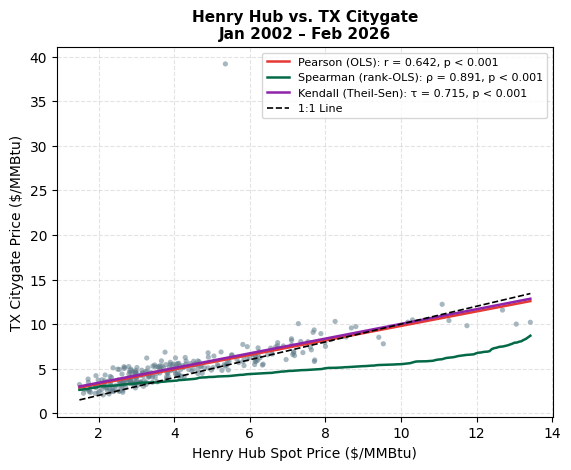

In [14]:
date_range = f"{merged.index[0].strftime('%b %Y')} \u2013 {merged.index[-1].strftime('%b %Y')}"

scatter_corr(
    x=merged["henry_hub"], y=merged["citygate"],
    xlabel="Henry Hub Spot Price ($/MMBtu)",
    ylabel="TX Citygate Price ($/MMBtu)",
    title=f"Henry Hub vs. TX Citygate\n{date_range}"
)

plt.savefig(OUT_DIR / "ng_price_correlations_henry_citygate.png", dpi=150)
plt.show()

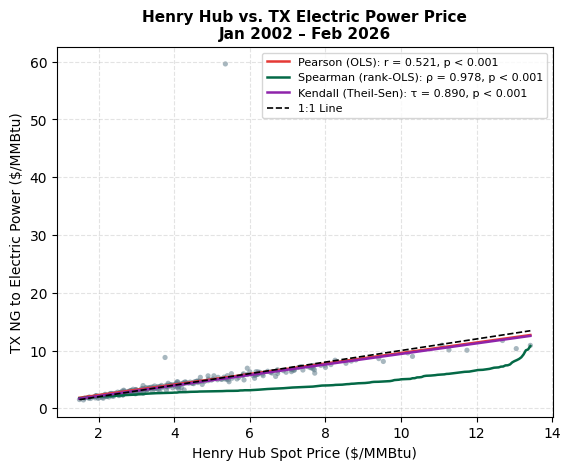

In [13]:
scatter_corr(
    x=merged["henry_hub"], y=merged["elec_pwr"],
    xlabel="Henry Hub Spot Price ($/MMBtu)",
    ylabel="TX NG to Electric Power ($/MMBtu)",
    title=f"Henry Hub vs. TX Electric Power Price\n{date_range}"
)
plt.savefig(OUT_DIR / "ng_price_correlations_henry_elec_pwr.png", dpi=150)
plt.show()

In [12]:
# Detect outliers in the merged dataset using Z-scores
merged.columns
merged['outlier_citygate'] = merged['citygate'] >= 2 * 0.84 * merged['henry_hub'] + 1.72
merged['outlier_elec_pwr'] = merged['elec_pwr'] >= 2 * 0.94 * merged['henry_hub'] + 0.48
merged[merged['outlier_citygate'] | merged['outlier_elec_pwr']]

,henry_hub,citygate,elec_pwr,outlier_citygate,outlier_elec_pwr
date,,,,,
2021-02-01,5.353684,39.181118,59.614644,True,True
2021-12-01,3.757727,6.849711,8.795761,False,True


In [27]:
out_csv = OUT_DIR / "ng_prices_monthly.csv"
merged.to_csv(out_csv)